--- Starting FGSM Adversarial Attack (VisDrone Multi-Class, SMOTE + Multi-Model) ---
TensorFlow Version: 2.20.0
Extracting...

Folder structure:
VisDrone2019-DET-val -> ['.DS_Store']
VisDrone2019-DET-val/annotations -> ['0000103_02964_d_0000030.txt', '0000277_01801_d_0000548.txt', '0000194_00399_d_0000121.txt', '0000271_01201_d_0000379.txt', '0000333_02353_d_0000013.txt']
VisDrone2019-DET-val/images -> ['0000283_00801_d_0000678.jpg', '0000291_05201_d_0000893.jpg', '0000287_03401_d_0000776.jpg', '0000327_03001_d_0000726.jpg', '0000316_01201_d_0000525.jpg']

Loading crops for car / truck / motor / background...
Class counts (before balancing): {'background': 548, 'car': 3903, 'truck': 282, 'motor': 208}
Training class counts (before SMOTE): {'background': 439, 'car': 3117, 'truck': 222, 'motor': 174}
Test class counts: {'background': 109, 'car': 786, 'truck': 60, 'motor': 34}

Applying SMOTE (k_neighbors=5) to balance training classes...
Training class counts (after SMOTE): {'background'

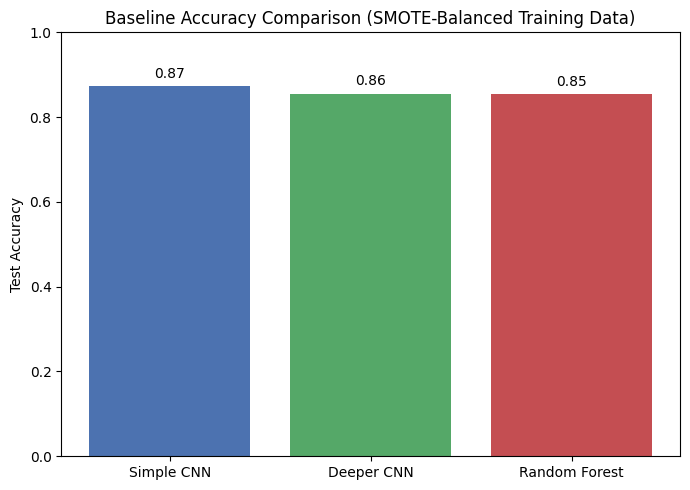


Running FGSM sweep for Simple CNN...
  epsilon=0.00 | acc=0.873 | precision=0.669 | recall=0.571 | FPR=0.105
  epsilon=0.01 | acc=0.426 | precision=0.223 | recall=0.167 | FPR=0.268
  epsilon=0.03 | acc=0.090 | precision=0.103 | recall=0.030 | FPR=0.367
  epsilon=0.05 | acc=0.016 | precision=0.027 | recall=0.005 | FPR=0.390
  epsilon=0.10 | acc=0.000 | precision=0.000 | recall=0.000 | FPR=0.399
  epsilon=0.15 | acc=0.001 | precision=0.001 | recall=0.002 | FPR=0.397
  epsilon=0.20 | acc=0.001 | precision=0.001 | recall=0.002 | FPR=0.395
  epsilon=0.30 | acc=0.004 | precision=0.005 | recall=0.009 | FPR=0.385

Running FGSM sweep for Deeper CNN...
  epsilon=0.00 | acc=0.855 | precision=0.718 | recall=0.586 | FPR=0.099
  epsilon=0.01 | acc=0.538 | precision=0.297 | recall=0.277 | FPR=0.213
  epsilon=0.03 | acc=0.415 | precision=0.266 | recall=0.209 | FPR=0.248
  epsilon=0.05 | acc=0.377 | precision=0.259 | recall=0.196 | FPR=0.258
  epsilon=0.10 | acc=0.327 | precision=0.247 | recall=0.170 

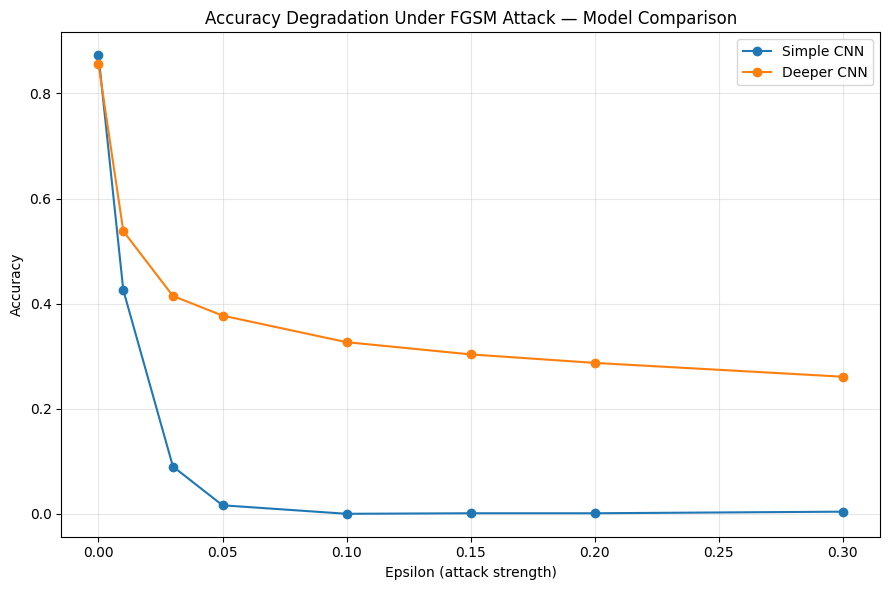

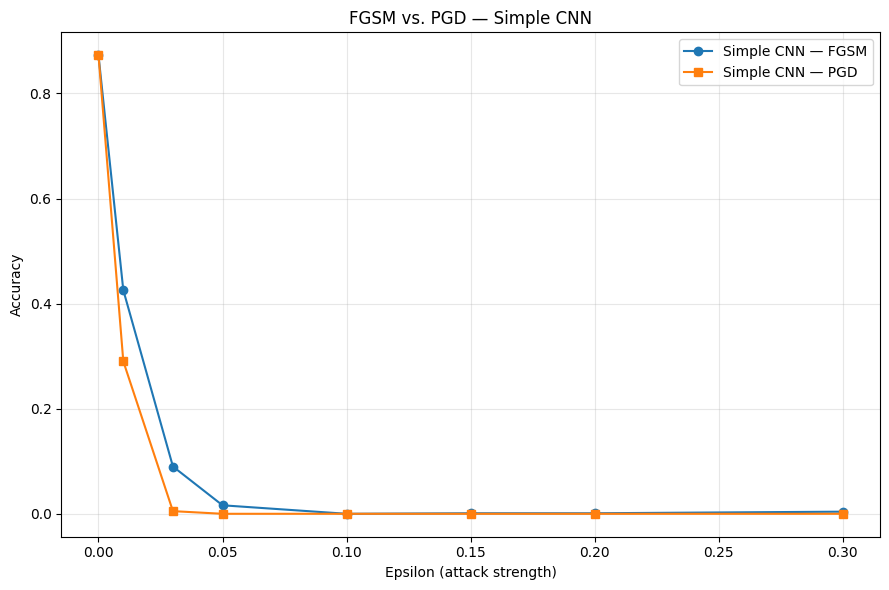

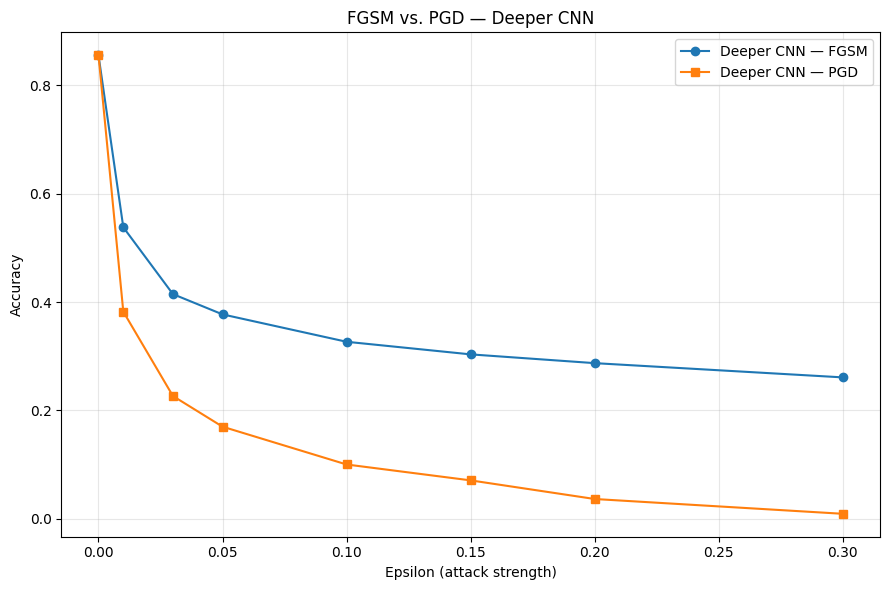

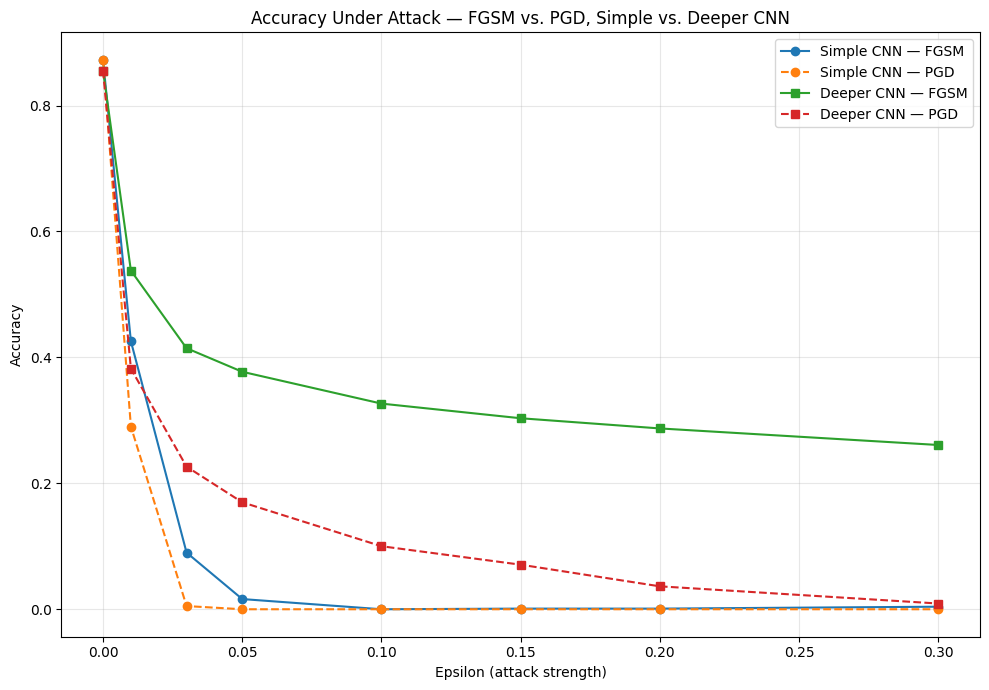

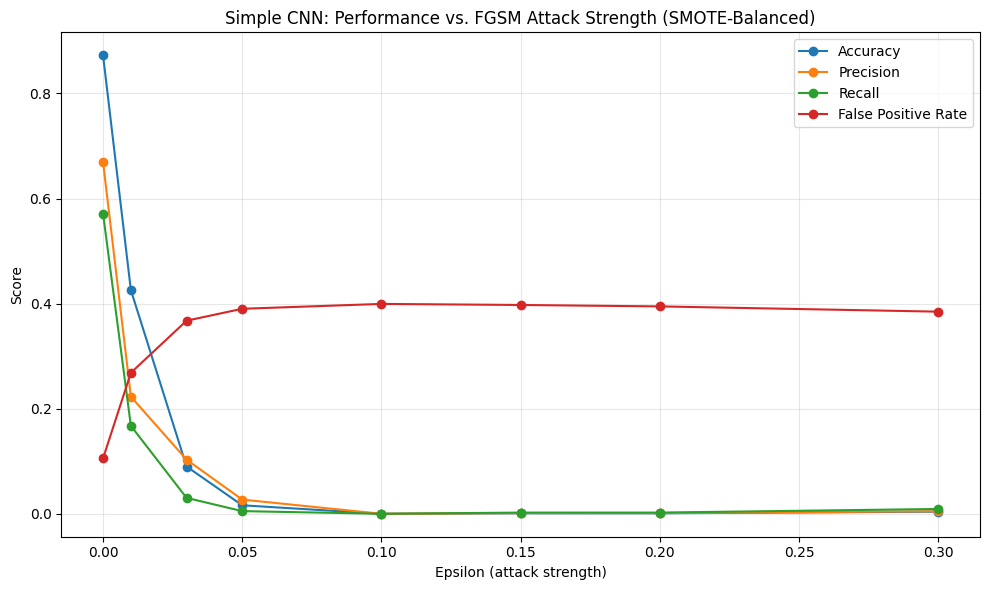

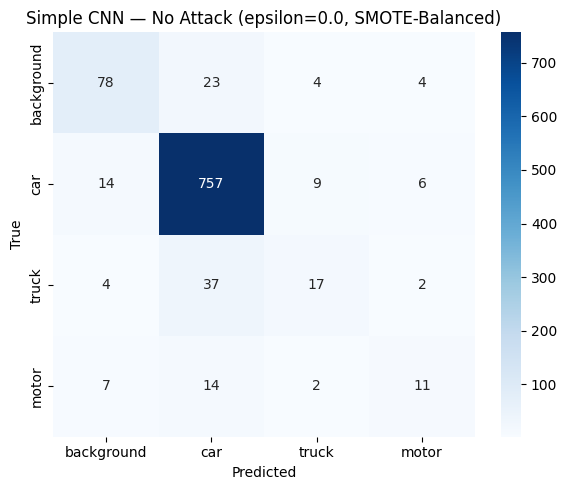

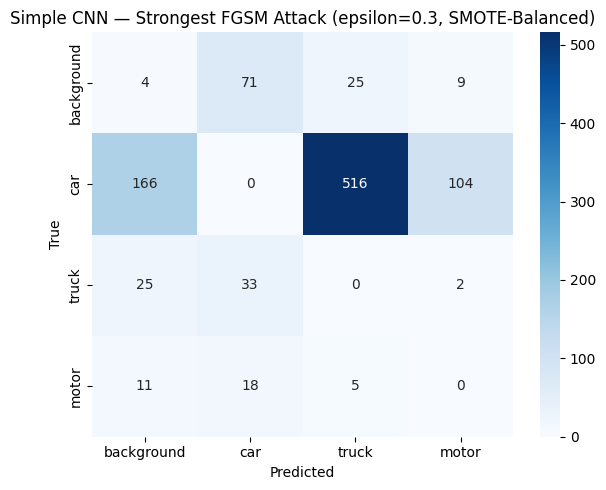

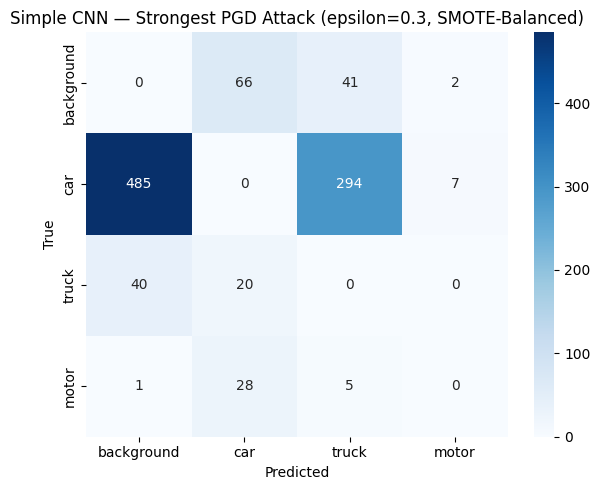


=== Summary: Accuracy under FGSM vs. PGD ===
 Epsilon |  Simple-FGSM |  Simple-PGD |  Deep-FGSM |  Deep-PGD
    0.00 |        0.873 |       0.873 |      0.855 |     0.855
    0.01 |        0.426 |       0.290 |      0.538 |     0.382
    0.03 |        0.090 |       0.005 |      0.415 |     0.226
    0.05 |        0.016 |       0.000 |      0.377 |     0.170
    0.10 |        0.000 |       0.000 |      0.327 |     0.100
    0.15 |        0.001 |       0.000 |      0.303 |     0.071
    0.20 |        0.001 |       0.000 |      0.287 |     0.036
    0.30 |        0.004 |       0.000 |      0.261 |     0.009


In [1]:


import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import cv2
import urllib.request
import zipfile
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import seaborn as sns

print("--- Starting FGSM Adversarial Attack (VisDrone Multi-Class, SMOTE + Multi-Model) ---")
print("TensorFlow Version:", tf.__version__)

# ===========================================================
# 1. Download VisDrone2019-DET-val
# ===========================================================
url = "https://github.com/ultralytics/yolov5/releases/download/v1.0/VisDrone2019-DET-val.zip"
zip_path = "VisDrone2019-DET-val.zip"

if not os.path.exists(zip_path):
    print("Downloading VisDrone val set...")
    urllib.request.urlretrieve(url, zip_path)

if not os.path.exists("VisDrone2019-DET-val"):
    print("Extracting...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")

print("\nFolder structure:")
for root, dirs, files in os.walk("VisDrone2019-DET-val"):
    print(root, "->", files[:5])

IMAGES_DIR = "VisDrone2019-DET-val/images"
ANNOTATIONS_DIR = "VisDrone2019-DET-val/annotations"


# ===========================================================
# 2. Load car / truck / motor / background crops
# ===========================================================
VISDRONE_CLASS_MAP = {4: "car", 6: "truck", 10: "motor"}
CLASS_NAMES = ["background", "car", "truck", "motor"]
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

IMG_SIZE = 64
MIN_BOX_SIZE = 40  # skip boxes smaller than this — tiny boxes just become blur when resized up

def load_crops(images_dir, annotations_dir, max_images=550):
    crops, labels = [], []
    ann_files = glob.glob(os.path.join(annotations_dir, "*.txt"))

    for ann_path in ann_files[:max_images]:
        base = os.path.splitext(os.path.basename(ann_path))[0]
        img_path = os.path.join(images_dir, base + ".jpg")
        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]

        with open(ann_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split(",")
            if len(parts) < 8:
                continue
            x, y, bw, bh, score, cls_id, trunc, occ = map(int, parts[:8])
            if cls_id not in VISDRONE_CLASS_MAP or bw <= 0 or bh <= 0:
                continue
            if bw < MIN_BOX_SIZE or bh < MIN_BOX_SIZE:
                continue

            crop = img[max(y, 0):y + bh, max(x, 0):x + bw]
            if crop.size == 0:
                continue
            crop = cv2.resize(crop, (IMG_SIZE, IMG_SIZE))
            crops.append(crop)
            labels.append(CLASS_TO_IDX[VISDRONE_CLASS_MAP[cls_id]])

        bg_x = np.random.randint(0, max(w - IMG_SIZE, 1))
        bg_y = np.random.randint(0, max(h - IMG_SIZE, 1))
        bg_crop = img[bg_y:bg_y + IMG_SIZE, bg_x:bg_x + IMG_SIZE]
        if bg_crop.shape[:2] == (IMG_SIZE, IMG_SIZE):
            crops.append(bg_crop)
            labels.append(CLASS_TO_IDX["background"])

    return crops, labels

print("\nLoading crops for car / truck / motor / background...")
crops, labels = load_crops(IMAGES_DIR, ANNOTATIONS_DIR)

X = np.array(crops, dtype=np.float32) / 255.0
y = np.array(labels)
print("Class counts (before balancing):", {name: int(np.sum(y == idx)) for name, idx in CLASS_TO_IDX.items()})

idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
split = int(0.8 * len(X))
x_train, x_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Training class counts (before SMOTE):", {name: int(np.sum(y_train == i)) for name, i in CLASS_TO_IDX.items()})
print("Test class counts:", {name: int(np.sum(y_test == i)) for name, i in CLASS_TO_IDX.items()})

# ===========================================================
# 3. Balance the TRAINING set with SMOTE
# ===========================================================
# SMOTE needs flat feature vectors, not images, so we flatten each 64x64x3 image
# into a single row, balance the classes, then reshape back into images.
n_train = x_train.shape[0]
x_train_flat = x_train.reshape(n_train, -1)  # (n_samples, 64*64*3)

# k_neighbors must be smaller than the smallest class's sample count
smallest_class_count = min(np.sum(y_train == i) for i in range(len(CLASS_NAMES)))
k_neighbors = max(1, min(5, smallest_class_count - 1))

print(f"\nApplying SMOTE (k_neighbors={k_neighbors}) to balance training classes...")
smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
x_train_flat_bal, y_train_bal = smote.fit_resample(x_train_flat, y_train)

x_train_bal = x_train_flat_bal.reshape(-1, IMG_SIZE, IMG_SIZE, 3)
x_train_bal = np.clip(x_train_bal, 0, 1)  # SMOTE interpolation can slightly overshoot [0,1]

print("Training class counts (after SMOTE):", {name: int(np.sum(y_train_bal == i)) for name, i in CLASS_TO_IDX.items()})

# ===========================================================
# 4. Model 1 — Original CNN (baseline architecture)
# ===========================================================
def build_simple_cnn():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        tf.keras.layers.Conv2D(16, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

print("\nTraining Model 1: Simple CNN (on SMOTE-balanced data)...")
model_cnn_simple = build_simple_cnn()
model_cnn_simple.fit(x_train_bal, y_train_bal, epochs=15, batch_size=32,
                      validation_data=(x_test, y_test))

# ===========================================================
# 5. Model 2 — Deeper CNN (more capacity, extra conv block + batch norm)
# ===========================================================
def build_deeper_cnn():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

print("\nTraining Model 2: Deeper CNN (on SMOTE-balanced data)...")
model_cnn_deep = build_deeper_cnn()
model_cnn_deep.fit(x_train_bal, y_train_bal, epochs=15, batch_size=32,
                    validation_data=(x_test, y_test))

# ===========================================================
# 6. Model 3 — Random Forest (classical ML baseline, non-neural)
# ===========================================================
# Random Forest can't be attacked with FGSM (no gradients), but it's a useful
# baseline to see whether a simple, non-deep-learning model does better/worse
# on this data before any attack is considered.
print("\nTraining Model 3: Random Forest (on SMOTE-balanced data)...")
x_test_flat = x_test.reshape(x_test.shape[0], -1)

model_rf = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
model_rf.fit(x_train_flat_bal, y_train_bal)
rf_preds = model_rf.predict(x_test_flat)
rf_accuracy = accuracy_score(y_test, rf_preds)
print(f"Random Forest test accuracy: {rf_accuracy:.3f}")

# ===========================================================
# 7. Compare baseline (clean, non-attacked) accuracy across all 3 models
# ===========================================================
cnn_simple_acc = model_cnn_simple.evaluate(x_test, y_test, verbose=0)[1]
cnn_deep_acc = model_cnn_deep.evaluate(x_test, y_test, verbose=0)[1]

print("\n--- Baseline accuracy comparison (no attack) ---")
print(f"Simple CNN:    {cnn_simple_acc:.3f}")
print(f"Deeper CNN:    {cnn_deep_acc:.3f}")
print(f"Random Forest: {rf_accuracy:.3f}")

plt.figure(figsize=(7, 5))
model_names = ["Simple CNN", "Deeper CNN", "Random Forest"]
accuracies = [cnn_simple_acc, cnn_deep_acc, rf_accuracy]
bars = plt.bar(model_names, accuracies, color=["#4C72B0", "#55A868", "#C44E52"])
plt.ylabel("Test Accuracy")
plt.title("Baseline Accuracy Comparison (SMOTE-Balanced Training Data)")
plt.ylim(0, 1)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.02, f"{acc:.2f}", ha='center')
plt.tight_layout()
plt.show()

# ===========================================================
# 8. FGSM across epsilon values — only for the two CNN models
#    (Random Forest has no gradients, so FGSM doesn't apply to it)
# ===========================================================
def fgsm_attack_batch(model, images, labels, epsilon):
    images_tensor = tf.cast(images, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(images_tensor)
        predictions = model(images_tensor)
        loss = tf.keras.losses.sparse_categorical_crossentropy(labels, predictions)
    gradients = tape.gradient(loss, images_tensor)
    signed_grad = tf.sign(gradients)
    adv_images = images_tensor + epsilon * signed_grad
    return tf.clip_by_value(adv_images, 0, 1)

def pgd_attack_batch(model, images, labels, epsilon, alpha=None, num_steps=10):
    """
    Projected Gradient Descent (PGD) — a stronger, iterative version of FGSM.
    Instead of one big step in the gradient-sign direction, it takes several
    SMALL steps, re-checking the gradient each time, and after every step it
    "projects" the result back so the total change never exceeds epsilon.
    This usually finds a more damaging perturbation than FGSM's single step.
    """
    if alpha is None:
        alpha = epsilon / 4  # step size per iteration (a common default)

    original_images = tf.cast(images, tf.float32)
    adv_images = tf.identity(original_images)

    # Start from a small random point within the epsilon ball (standard PGD practice)
    adv_images = adv_images + tf.random.uniform(
        adv_images.shape, minval=-epsilon, maxval=epsilon
    )
    adv_images = tf.clip_by_value(adv_images, 0, 1)

    for _ in range(num_steps):
        with tf.GradientTape() as tape:
            tape.watch(adv_images)
            predictions = model(adv_images)
            loss = tf.keras.losses.sparse_categorical_crossentropy(labels, predictions)
        gradients = tape.gradient(loss, adv_images)
        adv_images = adv_images + alpha * tf.sign(gradients)

        # Project back into the epsilon ball around the original image
        perturbation = tf.clip_by_value(adv_images - original_images, -epsilon, epsilon)
        adv_images = tf.clip_by_value(original_images + perturbation, 0, 1)

    return adv_images

def compute_false_positive_rate(y_true, y_pred, num_classes):
    cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))
    fpr_per_class = []
    total = cm.sum()
    for i in range(num_classes):
        fp = cm[:, i].sum() - cm[i, i]
        tn = total - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fpr_per_class.append(fpr)
    return np.mean(fpr_per_class)

def run_epsilon_sweep(model, model_label, attack_fn, attack_label):
    epsilons = [0.0, 0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.3]
    results = {"epsilon": [], "accuracy": [], "precision": [], "recall": [], "fpr": []}

    print(f"\nRunning {attack_label} sweep for {model_label}...")
    for eps in epsilons:
        if eps == 0.0:
            adv_x_test = tf.cast(x_test, tf.float32)  # no attack at epsilon=0
        else:
            adv_x_test = attack_fn(model, x_test, y_test, eps)
        preds = model.predict(adv_x_test, verbose=0)
        y_pred = np.argmax(preds, axis=1)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
        rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
        fpr = compute_false_positive_rate(y_test, y_pred, len(CLASS_NAMES))

        results["epsilon"].append(eps)
        results["accuracy"].append(acc)
        results["precision"].append(prec)
        results["recall"].append(rec)
        results["fpr"].append(fpr)

        print(f"  epsilon={eps:.2f} | acc={acc:.3f} | precision={prec:.3f} | recall={rec:.3f} | FPR={fpr:.3f}")

    return results

# --- FGSM sweeps (both models) ---
results_simple_fgsm = run_epsilon_sweep(model_cnn_simple, "Simple CNN", fgsm_attack_batch, "FGSM")
results_deep_fgsm = run_epsilon_sweep(model_cnn_deep, "Deeper CNN", fgsm_attack_batch, "FGSM")

# --- PGD sweeps (both models) ---
results_simple_pgd = run_epsilon_sweep(model_cnn_simple, "Simple CNN", pgd_attack_batch, "PGD")
results_deep_pgd = run_epsilon_sweep(model_cnn_deep, "Deeper CNN", pgd_attack_batch, "PGD")

# Keep old variable names pointing at FGSM results so the rest of the script
# (graphs/confusion matrices below) still works without further edits.
results_simple = results_simple_fgsm
results_deep = results_deep_fgsm

# ===========================================================
# 9. Graph: accuracy degradation comparison between the two CNN models
# ===========================================================
plt.figure(figsize=(9, 6))
plt.plot(results_simple["epsilon"], results_simple["accuracy"], marker='o', label="Simple CNN")
plt.plot(results_deep["epsilon"], results_deep["accuracy"], marker='o', label="Deeper CNN")
plt.xlabel("Epsilon (attack strength)")
plt.ylabel("Accuracy")
plt.title("Accuracy Degradation Under FGSM Attack — Model Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ===========================================================
# 8b. FGSM vs. PGD comparison — same model, two attacks
# ===========================================================
plt.figure(figsize=(9, 6))
plt.plot(results_simple_fgsm["epsilon"], results_simple_fgsm["accuracy"], marker='o', label="Simple CNN — FGSM")
plt.plot(results_simple_pgd["epsilon"], results_simple_pgd["accuracy"], marker='s', label="Simple CNN — PGD")
plt.xlabel("Epsilon (attack strength)")
plt.ylabel("Accuracy")
plt.title("FGSM vs. PGD — Simple CNN")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
plt.plot(results_deep_fgsm["epsilon"], results_deep_fgsm["accuracy"], marker='o', label="Deeper CNN — FGSM")
plt.plot(results_deep_pgd["epsilon"], results_deep_pgd["accuracy"], marker='s', label="Deeper CNN — PGD")
plt.xlabel("Epsilon (attack strength)")
plt.ylabel("Accuracy")
plt.title("FGSM vs. PGD — Deeper CNN")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# All four lines together — the full picture
plt.figure(figsize=(10, 7))
plt.plot(results_simple_fgsm["epsilon"], results_simple_fgsm["accuracy"], marker='o', linestyle='-', label="Simple CNN — FGSM")
plt.plot(results_simple_pgd["epsilon"], results_simple_pgd["accuracy"], marker='o', linestyle='--', label="Simple CNN — PGD")
plt.plot(results_deep_fgsm["epsilon"], results_deep_fgsm["accuracy"], marker='s', linestyle='-', label="Deeper CNN — FGSM")
plt.plot(results_deep_pgd["epsilon"], results_deep_pgd["accuracy"], marker='s', linestyle='--', label="Deeper CNN — PGD")
plt.xlabel("Epsilon (attack strength)")
plt.ylabel("Accuracy")
plt.title("Accuracy Under Attack — FGSM vs. PGD, Simple vs. Deeper CNN")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Full metric comparison for the simple CNN (kept from before)
plt.figure(figsize=(10, 6))
plt.plot(results_simple["epsilon"], results_simple["accuracy"], marker='o', label="Accuracy")
plt.plot(results_simple["epsilon"], results_simple["precision"], marker='o', label="Precision")
plt.plot(results_simple["epsilon"], results_simple["recall"], marker='o', label="Recall")
plt.plot(results_simple["epsilon"], results_simple["fpr"], marker='o', label="False Positive Rate")
plt.xlabel("Epsilon (attack strength)")
plt.ylabel("Score")
plt.title("Simple CNN: Performance vs. FGSM Attack Strength (SMOTE-Balanced)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ===========================================================
# 10. Confusion matrices — baseline vs. strongest attack (Simple CNN)
# ===========================================================
def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

preds_baseline = np.argmax(model_cnn_simple.predict(x_test, verbose=0), axis=1)
adv_x_strong = fgsm_attack_batch(model_cnn_simple, x_test, y_test, 0.3)
preds_strong = np.argmax(model_cnn_simple.predict(adv_x_strong, verbose=0), axis=1)

plot_confusion_matrix(y_test, preds_baseline, CLASS_NAMES,
                       "Simple CNN — No Attack (epsilon=0.0, SMOTE-Balanced)")
plot_confusion_matrix(y_test, preds_strong, CLASS_NAMES,
                       "Simple CNN — Strongest FGSM Attack (epsilon=0.3, SMOTE-Balanced)")

# Same, but for PGD at the strongest epsilon — direct visual comparison to the FGSM matrix above
adv_x_strong_pgd = pgd_attack_batch(model_cnn_simple, x_test, y_test, 0.3)
preds_strong_pgd = np.argmax(model_cnn_simple.predict(adv_x_strong_pgd, verbose=0), axis=1)
plot_confusion_matrix(y_test, preds_strong_pgd, CLASS_NAMES,
                       "Simple CNN — Strongest PGD Attack (epsilon=0.3, SMOTE-Balanced)")

# ===========================================================
# 11. Summary printout — FGSM vs PGD, both models, at every epsilon
# ===========================================================
print("\n=== Summary: Accuracy under FGSM vs. PGD ===")
print(f"{'Epsilon':>8} | {'Simple-FGSM':>12} | {'Simple-PGD':>11} | {'Deep-FGSM':>10} | {'Deep-PGD':>9}")
for i, eps in enumerate(results_simple_fgsm["epsilon"]):
    print(f"{eps:>8.2f} | {results_simple_fgsm['accuracy'][i]:>12.3f} | "
          f"{results_simple_pgd['accuracy'][i]:>11.3f} | "
          f"{results_deep_fgsm['accuracy'][i]:>10.3f} | "
          f"{results_deep_pgd['accuracy'][i]:>9.3f}")

